# Finding insights from jobs descriptions using NLP methods

We further analyze the job descriptions of job postings from the Lightcast dataset using NLP methods.
By applying TF-IDF feature extraction, building classifiers models, and visualize key skills as word clouds we can gain insight into the job market.

## Load the Dataset into Spark

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, udf, max
from pyspark.sql.types import BooleanType, StringType
from ast import literal_eval

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"


# Initialize Spark Session
spark = SparkSession.builder.appName("LightcastData").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", 20)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# Load Data
df = spark.read.option("header", "true").option("inferSchema", "true").option("multiLine","true").option("escape", "\"").csv("data/lightcast_job_postings.csv")

Py4JJavaError: An error occurred while calling o45.csv.
: java.util.ServiceConfigurationError: org.apache.spark.sql.sources.DataSourceRegister: Error accessing configuration file
	at java.base/java.util.ServiceLoader.fail(ServiceLoader.java:582)
	at java.base/java.util.ServiceLoader$LazyClassPathLookupIterator.parse(ServiceLoader.java:1173)
	at java.base/java.util.ServiceLoader$LazyClassPathLookupIterator.nextProviderClass(ServiceLoader.java:1206)
	at java.base/java.util.ServiceLoader$LazyClassPathLookupIterator.hasNextService(ServiceLoader.java:1221)
	at java.base/java.util.ServiceLoader$LazyClassPathLookupIterator.hasNext(ServiceLoader.java:1265)
	at java.base/java.util.ServiceLoader$2.hasNext(ServiceLoader.java:1300)
	at java.base/java.util.ServiceLoader$3.hasNext(ServiceLoader.java:1385)
	at scala.collection.convert.Wrappers$JIteratorWrapper.hasNext(Wrappers.scala:45)
	at scala.collection.Iterator.foreach(Iterator.scala:943)
	at scala.collection.Iterator.foreach$(Iterator.scala:943

In [2]:
df.dropna(subset=['BODY'])
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: string (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (nul

## TF-IDF feature engineering

In [3]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, CountVectorizer, IDF
from pyspark.sql.functions import col, size, trim

In [4]:
df0 = df.filter(col("BODY").isNotNull() & (trim(col("BODY")) != ""))

In [5]:
# breakdown the job descriptions into words
tokenizer = Tokenizer(inputCol="BODY", outputCol="jd_words_raw")
df1 = tokenizer.transform(df0)

In [6]:
# remove stop words e.g. the, a, and, I, me
remover = StopWordsRemover(inputCol="jd_words_raw", outputCol="jd_words")
# english stop words, and other common workds
remover.setStopWords(StopWordsRemover.loadDefaultStopWords("english") + [
    ' ', '  ', '   ', '    ',
    'work', 'works',
    'job', 'jobs',
    'position', 'positions',
    'skill', 'skills',
    'ability', 'abilities',
])
df2 = remover.transform(df1)

In [7]:
'''
# build hash term frequency
hashingTF = HashingTF(inputCol="jd_words", outputCol="features_raw", numFeatures=200)
df3 = hashingTF.transform(df2)
'''
# Word count using CountVectorizer
vectorizer = CountVectorizer(inputCol="jd_words", outputCol="features_raw", vocabSize=1000, minDF=2)
vectorizer_model = vectorizer.fit(df2)
df3 = vectorizer_model.transform(df2)

In [8]:
# compute IDF
idf = IDF(inputCol="features_raw", outputCol="features")
idf_model = idf.fit(df3)
df4 = idf_model.transform(df3)

### Top 30 most frequent words in job descriptions

In [9]:
from matplotlib import pyplot as plt

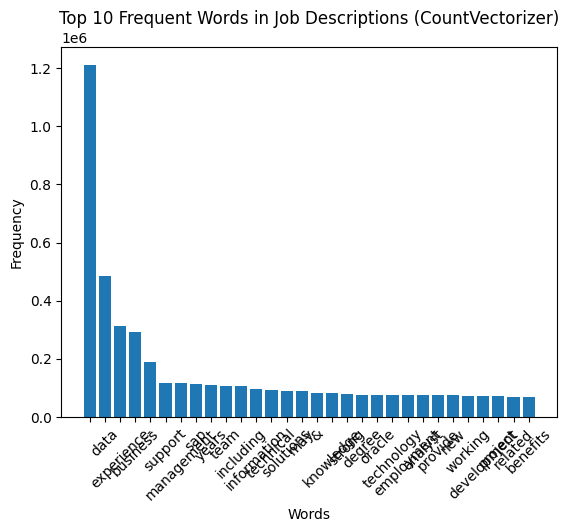

In [10]:
vocabulary = vectorizer_model.vocabulary
word_count_rdd = df3.select("features_raw").rdd.map(lambda row: row["features_raw"].toArray())

# Flatten the RDD and calculate frequency of each word index
flat_rdd = word_count_rdd.flatMap(lambda counts: zip(counts, range(len(counts))))
word_counts = flat_rdd.filter(lambda x: x[0] > 0).map(lambda x: (x[1], x[0])).reduceByKey(lambda a, b: a + b)

# Convert to a sorted list of tuples (word_index, count)
sorted_word_counts = sorted(word_counts.collect(), key=lambda x: x[1], reverse=True)

# Get the top N frequent words
top_n = 30
top_word_counts = sorted_word_counts[:top_n]

# Unzip the list of tuples to separate word indices and their counts
indices, counts = zip(*top_word_counts)

# Map the indices back to the actual words from the vocabulary
top_words = [vocabulary[i] for i in indices]

# Step 5: Visualize the result as a bar chart
plt.bar(top_words, counts)
plt.title('Top 10 Frequent Words in Job Descriptions (CountVectorizer)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate the x-axis labels to avoid overlap
plt.show()

## K-Means clustering based on job descrptions

In [12]:
from pyspark.ml.clustering import KMeans

k = 7
kmeans = KMeans(k=k, seed=42, featuresCol="features", predictionCol="topic")
kmeans_model = kmeans.fit(df4)
df5 = kmeans_model.transform(df4)

df5.select("BODY", "topic").show(5, truncate=False);

25/05/01 05:21:28 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Word Cloud Visualization

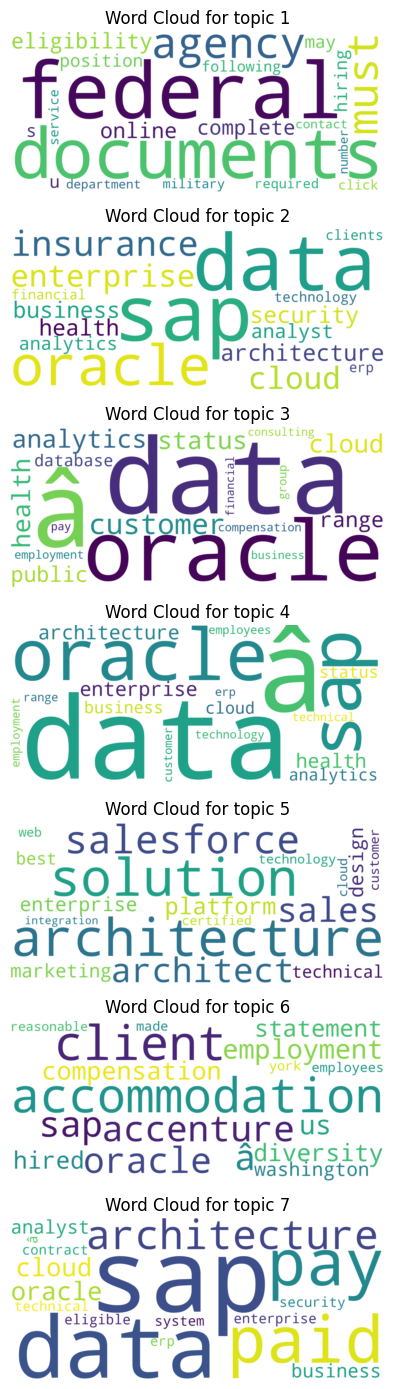

In [13]:
from wordcloud import WordCloud

centroids = kmeans_model.clusterCenters()
vocabulary = vectorizer_model.vocabulary

top_n = 20
plt.figure(figsize=(20, 14))
for i, centroid in enumerate(centroids):
    plt.subplot(k, 1, i + 1)
    top_words_indices = centroid.argsort()[-top_n:][::-1]  # Get indices of the top N words
    top_words = [vocabulary[index] for index in top_words_indices]
    
    wordcloud = WordCloud(width=1400, height=600, background_color="white").generate(" ".join(top_words))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud for topic {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Insights from the job description word clouds

1. Data science is skills is crucial. "Data" is frequent in every job posting cluster.
2. To excel on the job market, domain-specific knowledge are necessary besides general data science skills.